# 03 — TCGA Exploratory Data Analysis

This notebook explores the merged TCGA dataset produced by `02_tcga_data_loading.ipynb`, before any cleaning or feature selection is applied.

Goals:
- Understand the overall dataset structure and size
- Assess class balance for both the binary and multi-class targets
- Characterise the expression data distribution (raw RSEM values)
- Identify data quality issues: missing values, outlier samples, zero-expression genes
- Motivate the preprocessing decisions made in `04_tcga_preprocessing.ipynb`

> **Prerequisite**: run `02_tcga_data_loading.ipynb` first to generate `data/processed/tcga_merged_raw.csv.gz`.

## Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

PROCESSED_DIR = Path("../data/processed")

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [2]:
DATA_FILE = PROCESSED_DIR / "tcga_merged_raw.csv.gz"
assert DATA_FILE.exists(), f"Missing: {DATA_FILE} — run notebook 02 first."

print("Loading merged dataset...")
df = pd.read_csv(DATA_FILE, index_col=0, low_memory=False)

# Separate expression columns from label columns
LABEL_COLS = ['Mutated', 'Variant_Classification']
gene_cols  = [c for c in df.columns if c not in LABEL_COLS]

X = df[gene_cols]           # expression matrix (raw RSEM)
y_bin  = df['Mutated'].astype(int)
y_multi = df['Variant_Classification']

print(f"Shape: {df.shape[0]:,} patients × {df.shape[1]:,} columns")
print(f"  Gene columns  : {len(gene_cols):,}")
print(f"  Label columns : {len(LABEL_COLS)}")

Loading merged dataset...
Shape: 9,875 patients × 20,503 columns
  Gene columns  : 20,501
  Label columns : 2


---

## 1. Dataset overview

In [3]:
print("=== Data types ===")
print(df.dtypes.value_counts().to_string())
print()
print("=== Missing values ===")
total_missing = df.isnull().sum().sum()
print(f"Total NaN cells: {total_missing:,}")
if total_missing > 0:
    cols_with_nan = df.isnull().sum()
    cols_with_nan = cols_with_nan[cols_with_nan > 0]
    print(f"Columns with any NaN: {len(cols_with_nan):,}")
    print(cols_with_nan.sort_values(ascending=False).head(20).to_string())

=== Data types ===
float64    20501
int64          1
str            1

=== Missing values ===
Total NaN cells: 4,069,730
Columns with any NaN: 3,338
ZSWIM2        1690
HES3          1690
HPVC1         1690
HNRNPCL1      1690
HMGB4         1690
HIST1H4G      1690
HIST1H2BA     1690
HIST1H2AA     1690
HIGD1C        1690
SLC17A1       1690
SLC17A2       1690
H2BFM         1690
HDGFL1        1690
SLC22A24      1690
HBII-52-46    1690
HBII-52-45    1690
HBII-52-28    1690
HBII-52-27    1690
HBII-52-24    1690
HBBP1         1690


---

## 2. Class balance

### 2a. Binary target: TP53 mutated vs. wild-type

Mutated
Wild-type    6744
Mutated      3131

Mutation rate: 31.7%


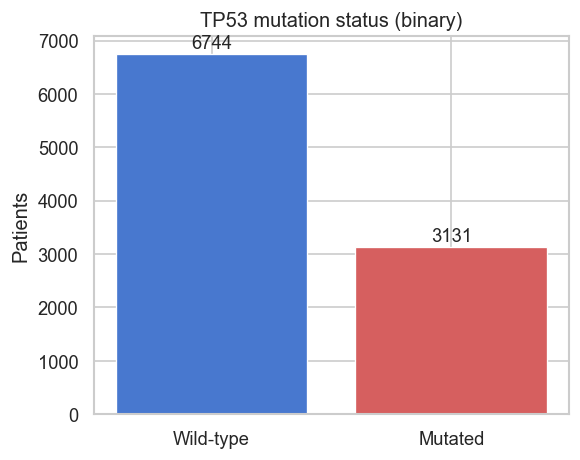

In [4]:
counts_bin = y_bin.value_counts().rename({0: 'Wild-type', 1: 'Mutated'})
print(counts_bin.to_string())
print(f"\nMutation rate: {counts_bin['Mutated'] / counts_bin.sum() * 100:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(counts_bin.index, counts_bin.values, color=['#4878CF', '#D65F5F'], edgecolor='white', linewidth=0.8)
for i, v in enumerate(counts_bin.values):
    ax.text(i, v + 30, str(v), ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Patients')
ax.set_title('TP53 mutation status (binary)')
plt.tight_layout()
plt.show()

### 2b. Multi-class target: mutation type breakdown

Variant_Classification
WT                   6744
Missense_Mutation    1949
Nonsense_Mutation     452
Frame_Shift_Del       298
Splice_Site           215
Frame_Shift_Ins        96
In_Frame_Del           59
Silent                 43
In_Frame_Ins            9
Intron                  5
3'UTR                   4
5'UTR                   1


/var/folders/bp/dy6w12yn1bgg5xmsdj1c8qg80000gn/T/ipykernel_93848/3051150302.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts_multi.index, rotation=30, ha='right')


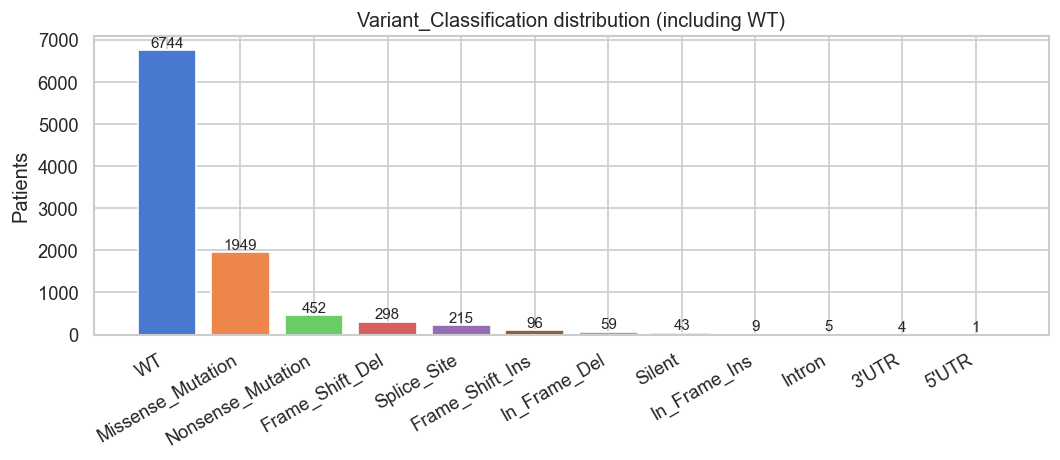

In [5]:
counts_multi = y_multi.value_counts()
print(counts_multi.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(counts_multi.index, counts_multi.values,
              color=sns.color_palette('muted', len(counts_multi)), edgecolor='white')
for bar, val in zip(bars, counts_multi.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            str(val), ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Patients')
ax.set_title('Variant_Classification distribution (including WT)')
ax.set_xticklabels(counts_multi.index, rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# Separate WT vs. mutated breakdown
mut_only = counts_multi[counts_multi.index != 'WT']
print("Mutation-type breakdown (TP53-mutant patients only):")
print(mut_only.to_string())
print(f"\nMissense fraction: {mut_only.get('Missense_Mutation', 0) / mut_only.sum() * 100:.1f}%")

Mutation-type breakdown (TP53-mutant patients only):
Variant_Classification
Missense_Mutation    1949
Nonsense_Mutation     452
Frame_Shift_Del       298
Splice_Site           215
Frame_Shift_Ins        96
In_Frame_Del           59
Silent                 43
In_Frame_Ins            9
Intron                  5
3'UTR                   4
5'UTR                   1

Missense fraction: 62.2%


---

## 3. Expression data quality

### 3a. Global value distribution

The expression values are raw RSEM units — not log-transformed. The distribution is expected to be highly right-skewed (most genes are lowly expressed).

In [7]:
# Sample 2M random values for the histogram (full matrix is ~2×10^8 values)
rng = np.random.default_rng(42)
flat_sample = rng.choice(X.values.ravel(), size=min(2_000_000, X.size), replace=False)

print("Global expression statistics (sampled):")
print(pd.Series(flat_sample).describe())

Global expression statistics (sampled):
count    1.959684e+06
mean     1.000784e+03
std      6.699992e+03
min     -9.912106e-01
25%      6.341199e+00
50%      2.006217e+02
75%      8.446402e+02
max      3.298360e+06
dtype: float64


/var/folders/bp/dy6w12yn1bgg5xmsdj1c8qg80000gn/T/ipykernel_93848/1620443244.py:18: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/elizabeth/opt/anaconda3/envs/tp53-predictor/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


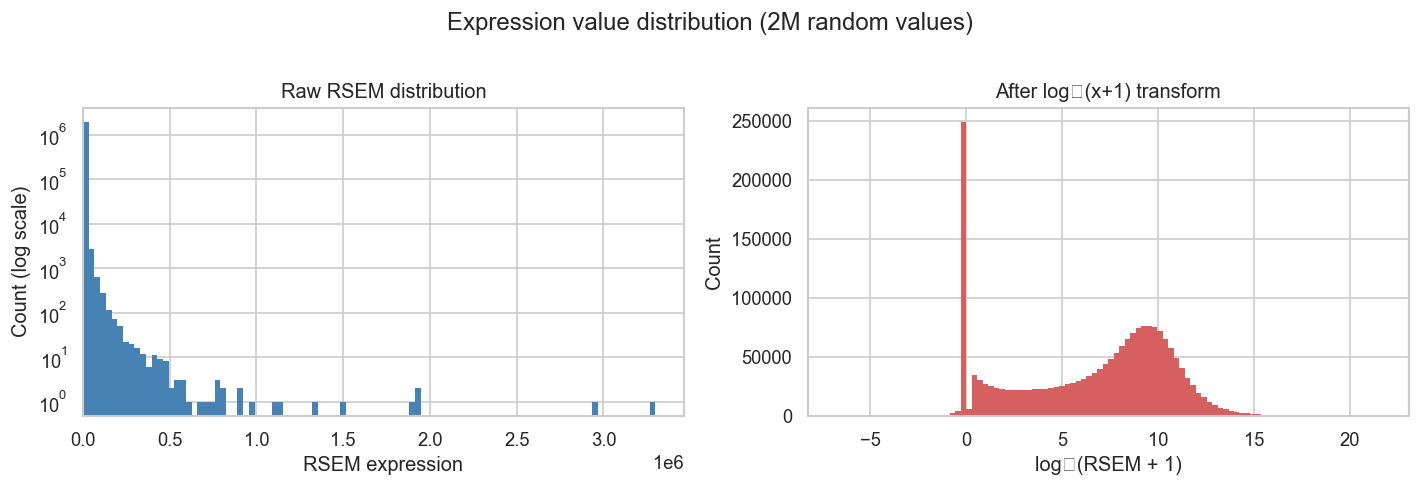


Log-transformed range: [nan, nan]


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw RSEM values
axes[0].hist(flat_sample, bins=100, color='steelblue', edgecolor='none', log=True)
axes[0].set_xlabel('RSEM expression')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Raw RSEM distribution')
axes[0].set_xlim(left=0)

# Log2(x + 1) transformed
log_sample = np.log2(flat_sample + 1)
axes[1].hist(log_sample, bins=100, color='#D65F5F', edgecolor='none')
axes[1].set_xlabel('log₂(RSEM + 1)')
axes[1].set_ylabel('Count')
axes[1].set_title('After log₂(x+1) transform')

plt.suptitle('Expression value distribution (2M random values)', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nLog-transformed range: [{log_sample.min():.2f}, {log_sample.max():.2f}]")

### 3b. Per-sample total expression (QC)

Outlier samples with unusually low total expression may represent failed sequencing runs.

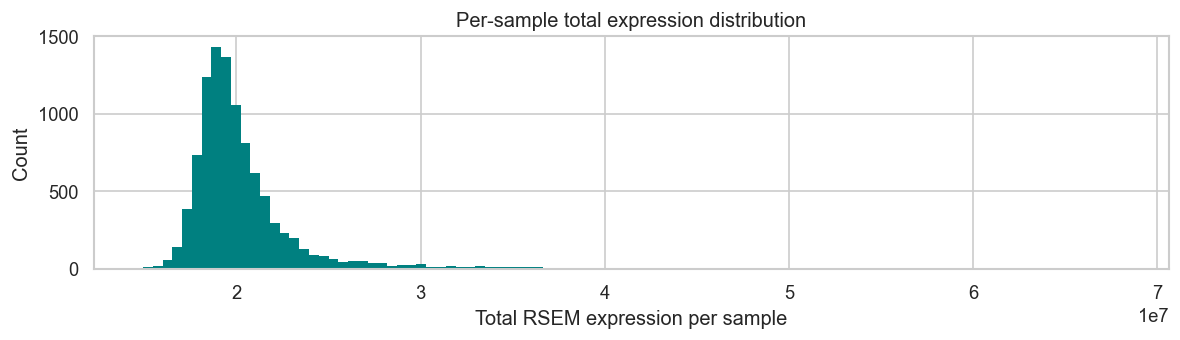

Samples with total < 1000: 0
Bottom 5 samples by total expression:
patient_id
TCGA-AB-2816    1.492399e+07
TCGA-AB-2901    1.503853e+07
TCGA-AB-2966    1.504468e+07
TCGA-AB-2840    1.509552e+07
TCGA-AB-2855    1.521843e+07


In [9]:
sample_totals = X.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(sample_totals, bins=100, color='teal', edgecolor='none')
ax.set_xlabel('Total RSEM expression per sample')
ax.set_ylabel('Count')
ax.set_title('Per-sample total expression distribution')
plt.tight_layout()
plt.show()

print(f"Samples with total < 1000: {(sample_totals < 1000).sum()}")
print(f"Bottom 5 samples by total expression:")
print(sample_totals.nsmallest(5).to_string())

### 3c. Per-gene mean expression

Many genes will have near-zero mean expression across all samples. These add noise without signal and will be removed in preprocessing.

Genes with mean RSEM == 0    : 220
Genes with mean RSEM  < 0.1  : 892
Genes with mean RSEM  < 1.0  : 1,733
Total genes                  : 20,501


/var/folders/bp/dy6w12yn1bgg5xmsdj1c8qg80000gn/T/ipykernel_93848/3881844054.py:13: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/elizabeth/opt/anaconda3/envs/tp53-predictor/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


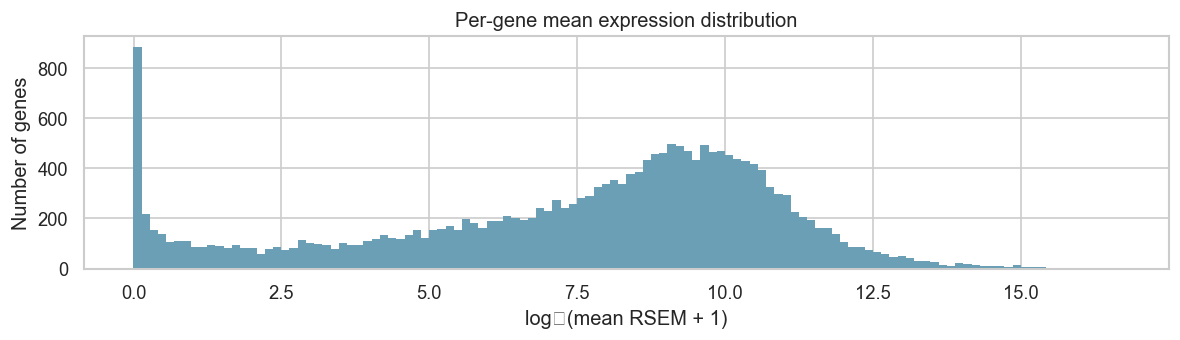

In [10]:
gene_means = X.mean(axis=0)

print(f"Genes with mean RSEM == 0    : {(gene_means == 0).sum():,}")
print(f"Genes with mean RSEM  < 0.1  : {(gene_means < 0.1).sum():,}")
print(f"Genes with mean RSEM  < 1.0  : {(gene_means < 1.0).sum():,}")
print(f"Total genes                  : {len(gene_means):,}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(np.log2(gene_means + 1), bins=120, color='#6A9FB5', edgecolor='none')
ax.set_xlabel('log₂(mean RSEM + 1)')
ax.set_ylabel('Number of genes')
ax.set_title('Per-gene mean expression distribution')
plt.tight_layout()
plt.show()

---

## 4. TP53 expression by mutation status

TP53 mRNA level is not a reliable solo predictor: many TP53 missense mutations are gain-of-function and the protein is overexpressed as a result, while wild-type TP53 is tightly regulated and often shows lower mRNA. This plot confirms that relationship.

/var/folders/bp/dy6w12yn1bgg5xmsdj1c8qg80000gn/T/ipykernel_93848/502033620.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Status', y='log2(TP53 RSEM+1)',


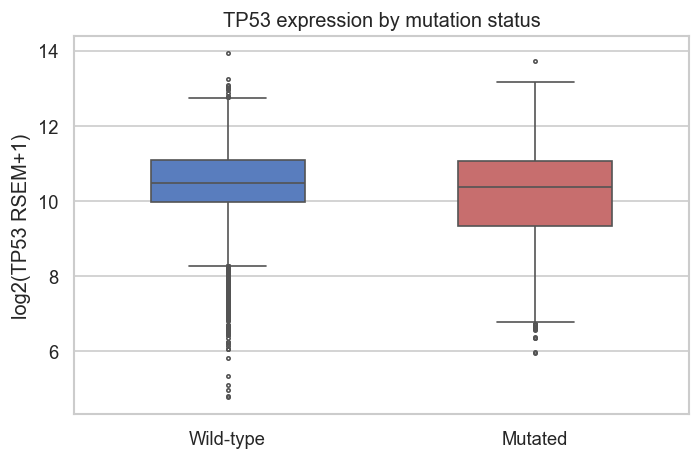

Median log2(TP53 RSEM+1) by group:
Status
Mutated      10.365644
Wild-type    10.476356


In [11]:
if 'TP53' in X.columns:
    tp53_log = np.log2(X['TP53'] + 1)
    plot_df = pd.DataFrame({'log2(TP53 RSEM+1)': tp53_log, 'Status': y_bin.map({0: 'Wild-type', 1: 'Mutated'})})

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.boxplot(data=plot_df, x='Status', y='log2(TP53 RSEM+1)',
                palette={'Wild-type': '#4878CF', 'Mutated': '#D65F5F'},
                width=0.5, ax=ax, fliersize=2)
    ax.set_title('TP53 expression by mutation status')
    ax.set_xlabel('')
    plt.tight_layout()
    plt.show()

    print("Median log2(TP53 RSEM+1) by group:")
    print(plot_df.groupby('Status')['log2(TP53 RSEM+1)'].median().to_string())
else:
    print("TP53 not found in expression columns.")

---

## 5. Missing values heatmap

Check whether missing values cluster in any specific region of the matrix.

In [12]:
nan_per_gene = X.isnull().sum(axis=0)
nan_per_sample = X.isnull().sum(axis=1)

print(f"Genes with ≥1 NaN: {(nan_per_gene > 0).sum():,} / {len(nan_per_gene):,}")
print(f"Samples with ≥1 NaN: {(nan_per_sample > 0).sum():,} / {len(nan_per_sample):,}")

if nan_per_gene.sum() > 0:
    # Show top genes by missingness
    print("\nTop 10 genes by NaN count:")
    print(nan_per_gene.nlargest(10).to_string())

Genes with ≥1 NaN: 3,338 / 20,501
Samples with ≥1 NaN: 1,690 / 9,875

Top 10 genes by NaN count:
ACCSL      1690
ACSM4      1690
ACTL9      1690
ACTRT2     1690
ADAD1      1690
ADAM3A     1690
AFM        1690
ANXA8L1    1690
ASB11      1690
ASB17      1690


---

## 6. PCA sanity check

A quick PCA on a random subset of genes to check whether mutated and wild-type samples cluster differently in gene expression space.

> We subsample 1,000 random genes (from the full ~20k) for speed — this is only exploratory.

In [13]:
N_GENES_PCA = 1000
rng = np.random.default_rng(0)
gene_subset = rng.choice(gene_cols, size=min(N_GENES_PCA, len(gene_cols)), replace=False)

X_sub = np.log2(X[gene_subset].fillna(0).values + 1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sub)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio (first 3 PCs):")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.2f}%")
print(f"  Cumulative: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Explained variance ratio (first 3 PCs):
  PC1: 10.19%
  PC2: 7.27%
  PC3: 5.16%
  Cumulative: 22.62%


/var/folders/bp/dy6w12yn1bgg5xmsdj1c8qg80000gn/T/ipykernel_93848/3972953676.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/elizabeth/opt/anaconda3/envs/tp53-predictor/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


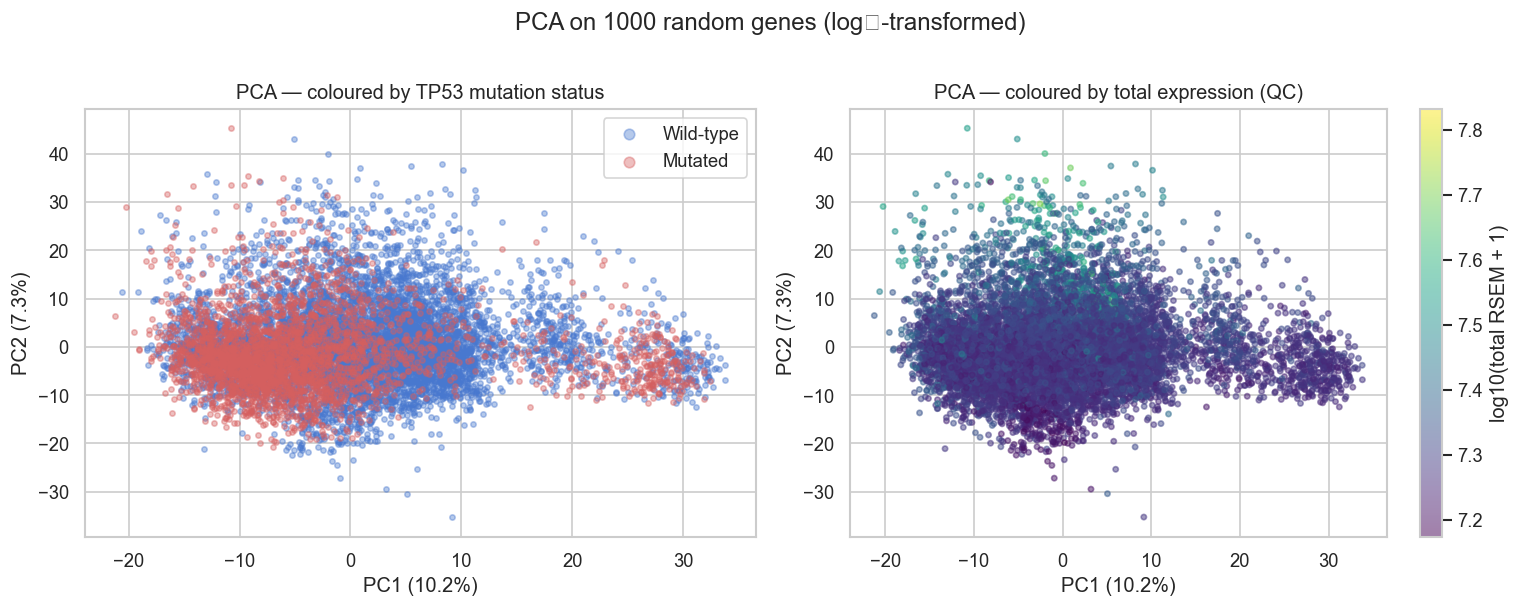

In [14]:
colors = ['#4878CF' if m == 0 else '#D65F5F' for m in y_bin]
labels_map = {0: 'Wild-type', 1: 'Mutated'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PC1 vs PC2 coloured by mutation status
for label_val, color, label_str in [(0, '#4878CF', 'Wild-type'), (1, '#D65F5F', 'Mutated')]:
    mask = y_bin == label_val
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, alpha=0.4, s=10, label=label_str)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title('PCA — coloured by TP53 mutation status')
axes[0].legend(markerscale=2)

# PC1 vs PC2 coloured by total expression (QC: spot failed samples)
totals = X.sum(axis=1).values
sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=np.log10(totals + 1), cmap='viridis', alpha=0.5, s=10)
plt.colorbar(sc, ax=axes[1], label='log10(total RSEM + 1)')
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title('PCA — coloured by total expression (QC)')

plt.suptitle(f'PCA on {N_GENES_PCA} random genes (log₂-transformed)', y=1.01)
plt.tight_layout()
plt.show()

---

## 7. Coefficient of variation per gene

We inspect the CV distribution to motivate the low-variance gene filter applied in preprocessing.

CV 10th percentile threshold : 0.0590
Genes below threshold (to drop): 2,050
Genes to retain               : 18,451


/var/folders/bp/dy6w12yn1bgg5xmsdj1c8qg80000gn/T/ipykernel_93848/3829741254.py:17: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/elizabeth/opt/anaconda3/envs/tp53-predictor/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


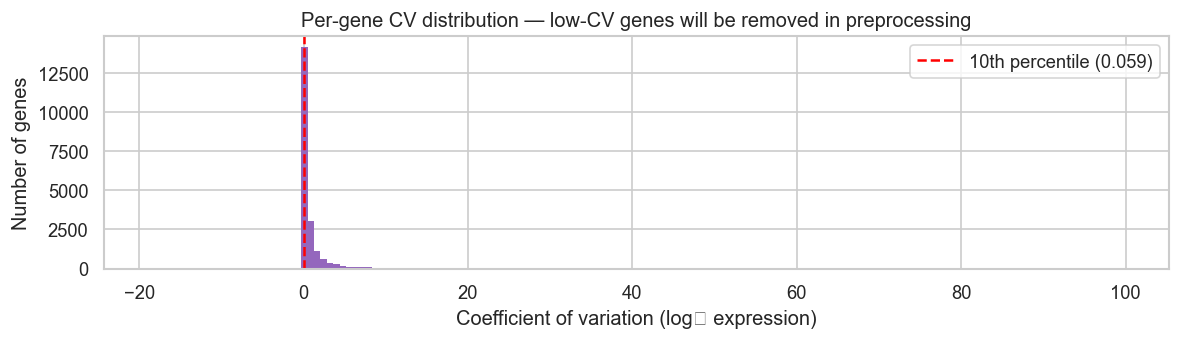

In [15]:
X_log = np.log2(X.fillna(0) + 1)

gene_cv = X_log.std(axis=0) / (X_log.mean(axis=0) + 1e-9)  # add epsilon to avoid div-by-zero

threshold_10 = gene_cv.quantile(0.10)
print(f"CV 10th percentile threshold : {threshold_10:.4f}")
print(f"Genes below threshold (to drop): {(gene_cv < threshold_10).sum():,}")
print(f"Genes to retain               : {(gene_cv >= threshold_10).sum():,}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(gene_cv, bins=150, color='#9467BD', edgecolor='none')
ax.axvline(threshold_10, color='red', linestyle='--', linewidth=1.5, label=f'10th percentile ({threshold_10:.3f})')
ax.set_xlabel('Coefficient of variation (log₂ expression)')
ax.set_ylabel('Number of genes')
ax.set_title('Per-gene CV distribution — low-CV genes will be removed in preprocessing')
ax.legend()
plt.tight_layout()
plt.show()

---

## 8. Key observations

> **Edit this cell** after running the notebook to record your findings.

### Expression data
- Raw RSEM values are right-skewed; log₂(x+1) transform gives a roughly bimodal distribution (unexpressed vs. expressed genes)
- Some genes have zero or near-zero expression across all samples → will be removed
- Per-sample total expression shows no obvious outlier clusters

### Labels
- Binary: moderate class imbalance (inspect exact counts above) — SMOTE or class weighting needed in modeling
- Multi-class: severe imbalance — Missense dominates; Frameshift and Splice are rare

### Missing values
- Inspect output of Section 5; if NaNs are few, fill with 0 is safe (unexpressed)

### PCA
- Whether mutated/WT clusters are visible in PC1-2 informs how linearly separable the problem is

### Preprocessing decisions motivated by EDA
1. **Log-transform**: confirmed by skewed raw distribution
2. **Zero-expression gene removal**: confirmed by `gene_means == 0` count
3. **CV filtering**: confirmed by wide CV distribution with many low-CV genes
4. **Class imbalance handling**: required for both tasks